# Blue Whale Heart Rates

By how much do blue whale heart rates change when they dive down to find food? 

The file `blue-whale-heart-rates.csv` contains heart rate data (measured in beats per minute) for blue whales. The data captures the dynamics of their heart rates as they dive over one hundred meters deep to forage for food. The heart rate measurements are taken approximately every 10 seconds during 8 separate dives.

### Dive Phases
The data records the heart rates corresponding to different dive states:
1. Descent: The whale begins its dive, descending into the depths.
2. Lunging: The whale opens its mouth and lunges upward, engulfing prey and water.
3. Filtering: After lunging, the whale sinks slightly and filters out water to retain food.
4. Ascent: The whale returns to the surface to breathe, marking the end of a dive.
5.  Surface: The blue whale is now on the surface (upper 5 meters)

The lunging and filtering process may occur multiple times on a single dive. The next dive cycle begins with another descent.

In [1]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'blue-whale-heart-rates.csv'.

# from google.colab import files
# uploaded = files.upload()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('blue-whale-heart-rates.csv')
df.head()


,timestamp,heart_rate,dive_id,dive_phase
0,8/27/18 17:10:10,NaN,2,descent
1,8/27/18 17:10:22,5.24,2,descent
2,8/27/18 17:10:31,6.55,2,descent
3,8/27/18 17:10:40,NaN,2,descent
4,8/27/18 17:10:48,NaN,2,descent


### Project Ideas

#### Warmup
Calculate the average heart rates for each dive phase.

#### Challenge
Investigate the relationship between dive duration and the maximum heart rate at the surface following the dive.

1. Data Preparation:
	- Convert the `timestamp` column to datetime format.

2. Calculate Dive Duration:
	- For each `dive_id`, identify the earliest timestamp for the descent phase.
	- For each `dive_id`, find the latest timestamp for the ascent phase.
	- Compute the `dive_duration` by subtracting the start of the descent from the end of the ascent, then convert this duration to minutes (`dt.total_seconds() / 60`).
	- Store the results in a new dataframe with 2 columns: `dive_id` and `dive_duration`.

3. Determine Maximum Surface Heart Rate:
	- Identify the maximum heart rate recorded at the surface after each dive.
	- Store the results in a new dataframe with 2 columns: `dive_id` and `max_surface_heart_rate`

4. Merge DataFrames:
	- Merge the dive duration and max surface heart rate dataframes.
	
5.	Visualize the Data:
	- Generate a scatter plot with dive duration on the x-axis and maximum surface heart rate on the y-axis to illustrate their relationship.

In [3]:
# YOUR CODE HERE (add additional cells as needed)

In [4]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"]
)

C:\Users\harsh\AppData\Local\Temp\ipykernel_20288\3917026941.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["timestamp"] = pd.to_datetime(


In [5]:
print(df.dtypes)

timestamp     datetime64[us]
heart_rate           float64
dive_id                int64
dive_phase               str
dtype: object


In [6]:
phase_avg = df.groupby(
    "dive_phase"
)["heart_rate"].mean()

print(phase_avg)

dive_phase
ascent     20.433318
descent     7.473607
filter      6.561053
lunge       9.773529
surface    32.546041
Name: heart_rate, dtype: float64


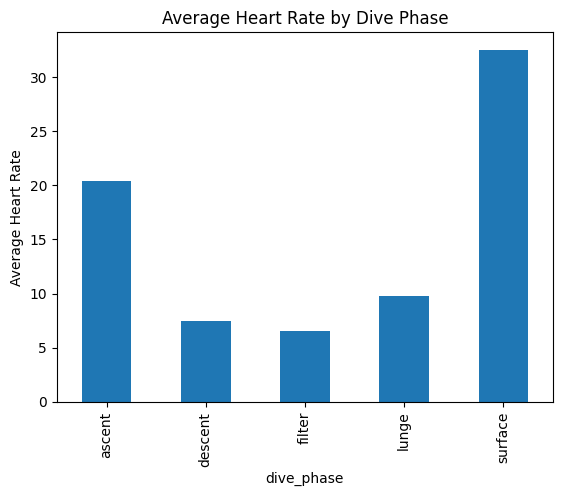

In [7]:
import matplotlib.pyplot as plt

phase_avg.plot.bar()

plt.ylabel("Average Heart Rate")

plt.title(
    "Average Heart Rate by Dive Phase"
)

plt.show()

In [8]:
descent = df[
    df["dive_phase"] == "descent"
]

In [11]:
start_times = descent.groupby(
    "dive_id"
)["timestamp"].min()
ascent = df[
    df["dive_phase"] == "ascent"
]
end_times = ascent.groupby(
    "dive_id"
)["timestamp"].max()
duration_df = pd.DataFrame({
    "start": start_times,
    "end": end_times
})

In [12]:
duration_df["dive_duration"] = (
    duration_df["end"] -
    duration_df["start"]
).dt.total_seconds() / 60

In [13]:
duration_df = duration_df.reset_index()

duration_df = duration_df[
    ["dive_id", "dive_duration"]
]

In [14]:
print(duration_df.head())

   dive_id  dive_duration
0        2      12.433333
1        3      12.400000
2        4       9.000000
3        5       9.616667
4        7      11.216667


In [15]:
surface = df[
    df["dive_phase"] == "surface"
]
surface_hr = surface.groupby(
    "dive_id"
)["heart_rate"].max()
surface_hr = (
    surface_hr
    .reset_index()
)
surface_hr = surface_hr.rename(
    columns={
        "heart_rate":
        "max_surface_heart_rate"
    }
)
print(surface_hr.head())

   dive_id  max_surface_heart_rate
0        2                   35.50
1        3                   35.29
2        4                   34.48
3        5                   33.90
4        7                   33.52


In [17]:
merged = pd.merge(
    duration_df,
    surface_hr,
    on="dive_id"
)
print(merged.head())

   dive_id  dive_duration  max_surface_heart_rate
0        2      12.433333                   35.50
1        3      12.400000                   35.29
2        4       9.000000                   34.48
3        5       9.616667                   33.90
4        7      11.216667                   33.52


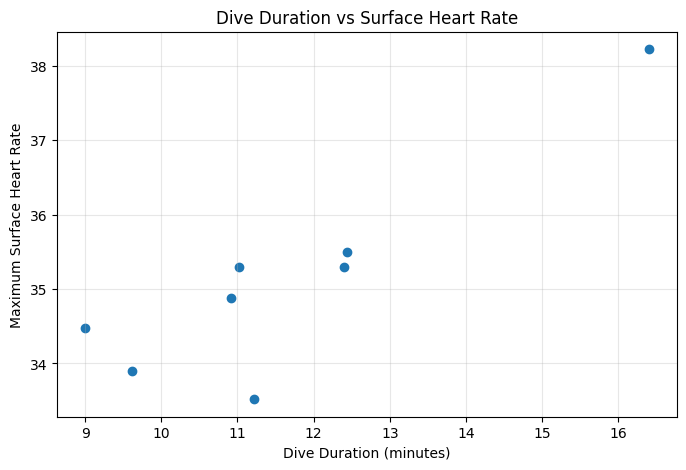

In [18]:
plt.figure(figsize=(8,5))

plt.scatter(
    merged["dive_duration"],
    merged["max_surface_heart_rate"]
)

plt.xlabel(
    "Dive Duration (minutes)"
)

plt.ylabel(
    "Maximum Surface Heart Rate"
)

plt.title(
    "Dive Duration vs Surface Heart Rate"
)

plt.grid(alpha=0.3)

plt.show()

In [19]:
correlation = merged[
    [
        "dive_duration",
        "max_surface_heart_rate"
    ]
].corr()

print(correlation)

                        dive_duration  max_surface_heart_rate
dive_duration                1.000000                0.884494
max_surface_heart_rate       0.884494                1.000000


In [20]:
merged.loc[
    merged[
        "dive_duration"
    ].idxmax()
]

dive_id                   11.00
dive_duration             16.40
max_surface_heart_rate    38.22
Name: 6, dtype: float64

In [22]:
merged.loc[
    merged[
        "max_surface_heart_rate"
    ].idxmin()
]

dive_id                    7.000000
dive_duration             11.216667
max_surface_heart_rate    33.520000
Name: 4, dtype: float64

<Axes: ylabel='Frequency'>

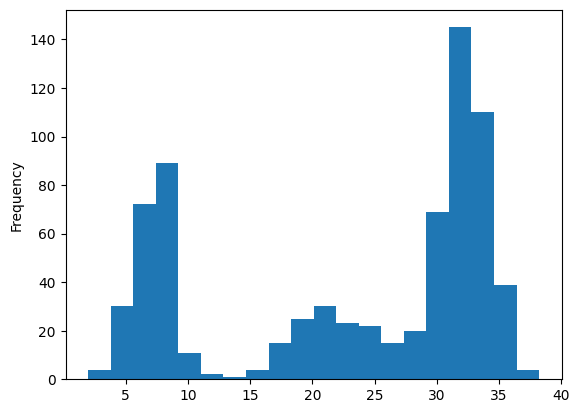

In [23]:
df["heart_rate"].plot.hist(
    bins=20
)